In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Setup Data Pipeline (Using your sample dataset for quick testing)
DATA_DIR = "./data_sample/"  # Ensure this points to your small sample folder!
IMG_SIZE = (224, 224)
BATCH_SIZE = 8  # Small batch size since we only have a few images locally

print("Loading datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# 2. Build the Model (Transfer Learning with MobileNetV2)
print("\nBuilding the model architecture...")
# Load the pre-trained MobileNetV2 model without its final classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, 
    weights='imagenet'
)
# Freeze the base model so we don't destroy its pre-trained knowledge
base_model.trainable = False 

# Create our custom classification head for binary classification (Cracked vs Intact)
model = tf.keras.Sequential([
    # Preprocess image pixel values to [-1, 1] as required by MobileNetV2
    tf.keras.layers.Rescaling(1./127.5, offset=-1), 
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    # Final output layer: 1 neuron with sigmoid activation (outputs a probability between 0 and 1)
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

# 3. Compile the Model
# Configuring the learning rate, loss function, and metrics
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
print("\nStarting the training process...")
EPOCHS = 3  # Run for just 3 cycles to check if everything works

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

print("\nSanity check complete: Training pipeline works perfectly!")

Loading datasets...
Found 80 files belonging to 2 classes.
Using 64 files for training.
Found 80 files belonging to 2 classes.
Using 16 files for validation.

Building the model architecture...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Starting the training process...
Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.4688 - loss: 0.7452 - val_accuracy: 0.8750 - val_loss: 0.4465
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9688 - loss: 0.3262 - val_accuracy: 0.9375 - val_loss: 0.2626
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9688 - loss: 0.1549 - val_accuracy: 0.9375 - val_loss: 0.1943

Sanity check complete: Training pipeline works perfectly!


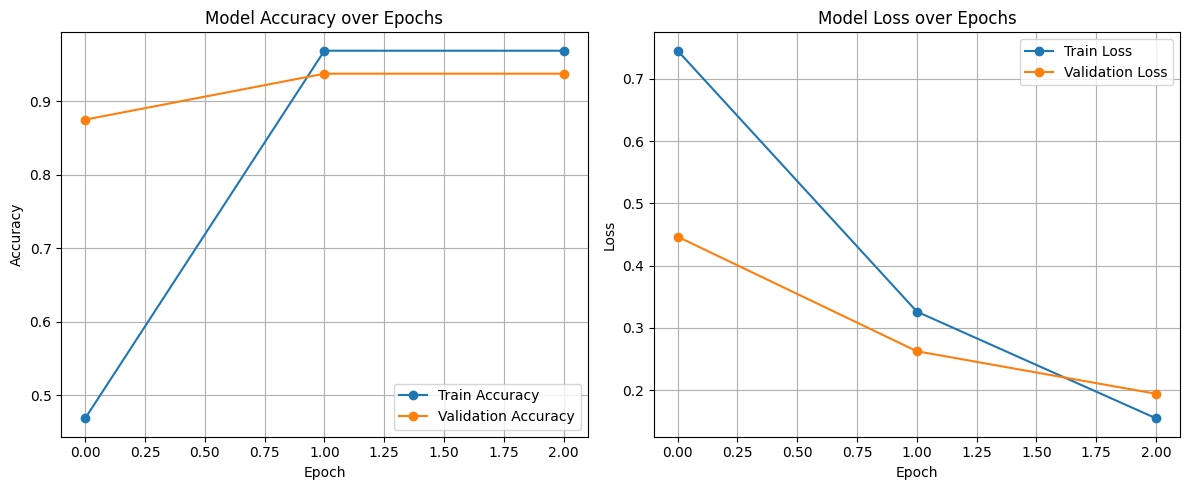

In [3]:
# 5. Plotting Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Generating predictions on validation data...

--- Classification Report ---
                    precision    recall  f1-score   support

 Negative (Intact)       0.86      1.00      0.92         6
Positive (Cracked)       1.00      0.90      0.95        10

          accuracy                           0.94        16
         macro avg       0.93      0.95      0.94        16
      weighted avg       0.95      0.94      0.94        16


--- Confusion Matrix ---


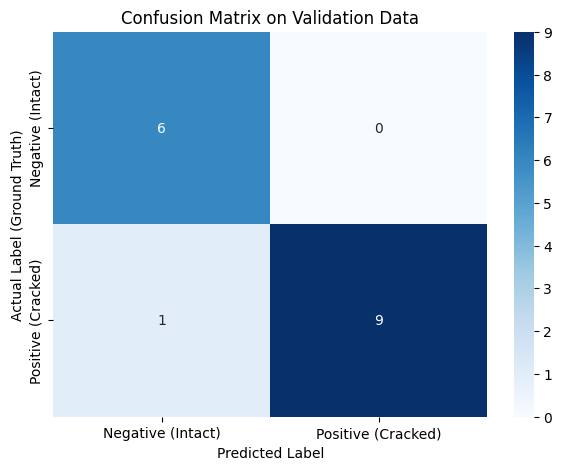

In [4]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Generating predictions on validation data...")

true_labels = []
predictions = []

# Extract true labels and get model predictions batch by batch
for images, labels in val_dataset:
    true_labels.extend(labels.numpy())
    
    # Model outputs a probability between 0 and 1
    batch_preds = model.predict(images, verbose=0)
    predictions.extend(batch_preds)

true_labels = np.array(true_labels)
predictions = np.array(predictions)

# Convert probabilities to binary classes (0 or 1) using 0.5 threshold
# If probability > 0.5, it predicts 1 (Positive/Cracked)
predicted_classes = (predictions > 0.5).astype(int).flatten()

target_names = ['Negative (Intact)', 'Positive (Cracked)']

# Print Classification Report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(true_labels, predicted_classes, target_names=target_names))

# Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_labels, predicted_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix on Validation Data')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label')
plt.show()